In [1]:
"""
Imported 7 datasets from American Housing Survey from 2011 - 2023 (biannual)
Automated the datasets by creating a file list and year extraction function
Combined all datasets into a single dataset for multi-year analysis
"""
import pandas as pd
import os
from google.colab import files

files.upload()

files_list = [
    'AHS TABLE5 2011.csv',
    'AHS TABLE5 2013.csv',
    'AHS TABLE5 2015.csv',
    'AHS TABLE5 2017.csv',
    'AHS TABLE5 2019.csv',
    'AHS TABLE5 2021.csv',
    'AHS TABLE5 2023.csv'
]

print("Files in folder:", os.listdir())

def extract_year(filename: str) -> int:
    # Works for: "AHS TABLE5 2011.csv"
    return int(filename.split()[-1].replace(".csv", ""))

def clean_text(x) -> str:
    return (
        str(x)
        .replace("\xa0", " ")   # non-breaking space
        .strip()
    )

def normalize_spaces(s: str) -> str:
    return " ".join(clean_text(s).split())

def parse_estimate(x):
    """
    Returns (estimate_raw, estimate_numeric, flag)
    - estimate_raw: original string
    - estimate_numeric: float or NA
    - flag: one of {'ok','suppressed','zero_round','blank_or_na','other_non_numeric'}
    """
    if pd.isna(x):
        return (pd.NA, pd.NA, "blank_or_na")

    raw = clean_text(x)

    # common AHS markers
    if raw == "":
        return ("", pd.NA, "blank_or_na")
    if raw in {"S"}:
        return ("S", pd.NA, "suppressed")
    if raw in {"Z"}:
        # "Z rounds to zero"
        return ("Z", 0.0, "zero_round")
    if raw in {"."}:
        return (".", pd.NA, "blank_or_na")

    # remove commas and attempt numeric conversion
    raw_no_commas = raw.replace(",", "")
    num = pd.to_numeric(raw_no_commas, errors="coerce")

    if pd.isna(num):
        return (raw, pd.NA, "other_non_numeric")
    return (raw, float(num), "ok")

def read_ahs_tablecreator(filepath: str) -> pd.DataFrame:
    year = extract_year(filepath)

    # Tables have a header row like "Household Income"
    # Then income categories row
    # Then "Estimate" row
    # This matches reading header rows [1,2] (0-based):
    # row2 + row3 in the sheet.
    df = pd.read_csv(filepath, header=[1, 2])

    # Flatten columns safely:
    # First column = Characteristics; remaining columns = income group names
    flat_cols = []
    for i, col in enumerate(df.columns):
        if i == 0:
            flat_cols.append("characteristic")
        else:
            # keep the top header level (income group)
            flat_cols.append(normalize_spaces(col[0]))
    df.columns = flat_cols

    # drop completely empty rows
    df = df.dropna(how="all")

    # clean characteristic text
    df["characteristic"] = df["characteristic"].astype(str).apply(normalize_spaces)

    # identify which columns hold numeric/suppression values
    value_cols = [c for c in df.columns if c != "characteristic"]

    # create a raw copy for flags before numeric conversion
    # We'll compute section headers based on value_cols being blank
    # but do it after parsing.
    parsed_frames = []
    for c in value_cols:
        parsed = df[c].apply(parse_estimate)
        df[f"{c}__raw"] = parsed.apply(lambda t: t[0])
        df[f"{c}__num"] = parsed.apply(lambda t: t[1])
        df[f"{c}__flag"] = parsed.apply(lambda t: t[2])

    # A "section" row is one where all numeric values are NA AND the raw values are blank
    num_cols = [f"{c}__num" for c in value_cols]
    raw_cols = [f"{c}__raw" for c in value_cols]

    is_section = (
        df[num_cols].isna().all(axis=1) &
        df[raw_cols].apply(lambda r: all((pd.isna(v) or v in {"", ".", pd.NA}) for v in r), axis=1) &
        (df["characteristic"] != "") &
        (df["characteristic"].str.lower() != "nan")
    )

    # build section column and forward fill
    df["section"] = pd.NA
    df.loc[is_section, "section"] = df.loc[is_section, "characteristic"]
    df["section"] = df["section"].ffill()

    # remove the section header rows from actual data
    df = df[~is_section].copy()

    # Reshape into tidy form.
    # Then melt raw, num, and flag.
    long_parts = []

    # Melt numeric
    num_long = df.melt(
        id_vars=["section", "characteristic"],
        value_vars=num_cols,
        var_name="income_group",
        value_name="estimate"
    )
    num_long["income_group"] = num_long["income_group"].str.replace("__num", "", regex=False)

    # Melt raw
    raw_long = df.melt(
        id_vars=["section", "characteristic"],
        value_vars=raw_cols,
        var_name="income_group",
        value_name="estimate_raw"
    )
    raw_long["income_group"] = raw_long["income_group"].str.replace("__raw", "", regex=False)

    # Melt flags
    flag_long = df.melt(
        id_vars=["section", "characteristic"],
        value_vars=[f"{c}__flag" for c in value_cols],
        var_name="income_group",
        value_name="flag"
    )
    flag_long["income_group"] = flag_long["income_group"].str.replace("__flag", "", regex=False)

    # Merge the three tables
    long_df = num_long.merge(
        raw_long, on=["section", "characteristic", "income_group"], how="left"
    ).merge(
        flag_long, on=["section", "characteristic", "income_group"], how="left"
    )

    # Add year
    long_df["year"] = year

    # Clean income_group text
    long_df["income_group"] = long_df["income_group"].astype(str).apply(normalize_spaces)
    long_df["section"] = long_df["section"].astype(str).apply(normalize_spaces)
    long_df["characteristic"] = long_df["characteristic"].astype(str).apply(normalize_spaces)

    # Drop rows that are empty
    long_df = long_df[~(long_df["estimate"].isna() & long_df["estimate_raw"].isna())]

    # Reorder columns
    long_df = long_df[["year", "section", "characteristic", "income_group", "estimate_raw", "estimate", "flag"]]

    return long_df

#Build the combined dataset
all_years = []
for f in files_list:
    all_years.append(read_ahs_tablecreator(f))

combined = pd.concat(all_years, ignore_index=True)

# Remove true duplicates
combined = combined.drop_duplicates(
    subset=["year", "section", "characteristic", "income_group"]
).sort_values(
    ["year", "section", "characteristic", "income_group"]
).reset_index(drop=True)

print(combined.head(20))
print("Years:", sorted(combined["year"].unique()))
print("Rows:", combined.shape[0])



#Print rows where Basement has suppressed estimate 'S'
basement_S = combined[
    (combined["characteristic"].str.lower() == "basement") &
    (combined["estimate_raw"] == "S")
]
print("\nBasement rows with S:")
print(basement_S[["year","section","characteristic","income_group","estimate_raw","flag"]])

#Print all "Mold"- related rows (section == Mold)
mold_rows = combined[combined["section"].str.lower() == "mold"]
print("\nExample Mold rows:")
print(mold_rows.head(15))

#Save merged dataset
combined.to_csv("AHS_HousingQuality_byIncome_2011_2023_tidy.csv", index=False)
print("\nSaved file: AHS_HousingQuality_byIncome_2011_2023_tidy.csv")



Saving AHS TABLE5 2011.csv to AHS TABLE5 2011 (1).csv
Saving AHS TABLE5 2013.csv to AHS TABLE5 2013 (1).csv
Saving AHS TABLE5 2015.csv to AHS TABLE5 2015 (1).csv
Saving AHS TABLE5 2017.csv to AHS TABLE5 2017 (1).csv
Saving AHS TABLE5 2019.csv to AHS TABLE5 2019 (1).csv
Saving AHS TABLE5 2021.csv to AHS TABLE5 2021 (1).csv
Saving AHS TABLE5 2023.csv to AHS TABLE5 2023 (1).csv
Files in folder: ['.config', 'AHS TABLE5 2011 (1).csv', 'AHS TABLE5 2023.csv', 'AHS TABLE5 2017.csv', 'AHS TABLE5 2015 (1).csv', 'AHS TABLE5 2011.csv', 'AHS TABLE5 2021.csv', 'AHS TABLE5 2019 (1).csv', 'AHS TABLE5 2017 (1).csv', 'AHS TABLE5 2021 (1).csv', 'AHS TABLE5 2023 (1).csv', 'AHS TABLE5 2015.csv', 'AHS_HousingQuality_byIncome_2011_2023_tidy.csv', 'Final_AHS_HousingQuality_byIncome_2011_2023_tidy.csv', 'AHS TABLE5 2013 (1).csv', 'AHS TABLE5 2019.csv', 'AHS_HousingQuality_with_estimate_log.csv', 'AHS TABLE5 2013.csv', 'summary_table_describe.csv', 'sample_data']
    year                              section ch

In [2]:
from google.colab import files
files.download("AHS_HousingQuality_byIncome_2011_2023_tidy.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
"""
Looks at the dataset called 'combined' and removes rows where
'characteristics == total and 'income_group' == total
and removes rows missing 'section'
then saves the new dataset as 'Final_AHS_HousingQuality_byIncome_2011_2023_tidy.csv'
"""
analysis_df = combined[
    (combined["characteristic"].str.lower() != "total") &
    (combined["income_group"].str.lower() != "total")
].copy()
#Drop rows without sections
analysis_df = analysis_df[analysis_df["section"].notna()]
analysis_df.head(20)
analysis_df.to_csv("Final_AHS_HousingQuality_byIncome_2011_2023_tidy.csv", index=False)
from google.colab import files
files.download("Final_AHS_HousingQuality_byIncome_2011_2023_tidy.csv")
print(analysis_df.isnull().sum())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

year                 0
section              0
characteristic       0
income_group         0
estimate_raw         0
estimate          1477
flag                 0
dtype: int64


In [4]:
"""
Saves the statistics of 'estimate' column into summary_table_describe.csv
Calculates the of 'estimate' into 'AHS_HousingQuality_with_estimate_log.csv'
"""
import numpy as np
summary_table = analysis_df["estimate"].describe() # summary statistics of 'estimate' column
summary_table.to_csv("summary_table_describe.csv") # exports the statistics into a file
from google.colab import files
files.download("summary_table_describe.csv") # dowloads the file from Colab into my computer

#Forces all values in "estimate" to be numeric
analysis_df["estimate"] = pd.to_numeric(
    analysis_df["estimate"],
    errors="coerce"
)
#Update final AHS dataset with estimate log (of the skewed housing risks couunts )
analysis_df['estimate_log'] = np.log1p(analysis_df['estimate'])# formula used: log(1+estimate)
output_filename = "AHS_HousingQuality_with_estimate_log.csv"
analysis_df.to_csv(output_filename, index=False)
files.download(output_filename)
print(analysis_df.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    year                              section characteristic  \
11  2011  Electric Fuses and Circuit Breakers         1 time   
12  2011  Electric Fuses and Circuit Breakers         1 time   
13  2011  Electric Fuses and Circuit Breakers         1 time   
14  2011  Electric Fuses and Circuit Breakers         1 time   
15  2011  Electric Fuses and Circuit Breakers         1 time   

            income_group estimate_raw  estimate flag  estimate_log  
11    $10,000 to $19,999          545     545.0   ok      6.302619  
12  $100,000 to $119,999          366     366.0   ok      5.905362  
13      $120,000 or more          931     931.0   ok      6.837333  
14    $20,000 to $29,999          628     628.0   ok      6.444131  
15    $30,000 to $39,999          524     524.0   ok      6.263398  


In [5]:
"""
Performs data quality analysis on the dataset called 'analysis_df'
includes: missing values, column data types, duplicate rows, summary statistics, unique values in each column
"""
def data_quality_report(df):
    print("🔍 Missing Values:\n", analysis_df.isnull().sum(), "\n")
    print("📊 Data Types:\n", analysis_df.dtypes, "\n")
    print("🗂 Duplicate Rows:", analysis_df.duplicated().sum(), "\n")
    print("📈 Summary Stats:\n", analysis_df.describe(), "\n")

    for col in analysis_df.select_dtypes(include=['object']).columns:
        print(f"🔢 Unique values in {col}:\n", analysis_df[col].unique(), "\n")

# Run the function
data_quality_report(analysis_df)


🔍 Missing Values:
 year                 0
section              0
characteristic       0
income_group         0
estimate_raw         0
estimate          1477
flag                 0
estimate_log      1477
dtype: int64 

📊 Data Types:
 year                int64
section            object
characteristic     object
income_group       object
estimate_raw       object
estimate          float64
flag               object
estimate_log      float64
dtype: object 

🗂 Duplicate Rows: 0 

📈 Summary Stats:
               year      estimate  estimate_log
count  8280.000000   6803.000000   6803.000000
mean   2018.157488   1999.004410      5.918057
std       4.211274   3847.448496      1.867693
min    2011.000000      0.000000      0.000000
25%    2015.000000    104.000000      4.653960
50%    2019.000000    252.000000      5.533389
75%    2023.000000   1110.000000      7.013015
max    2023.000000  26492.000000     10.184636 

🔢 Unique values in section:
 ['Electric Fuses and Circuit Breakers' 'External 

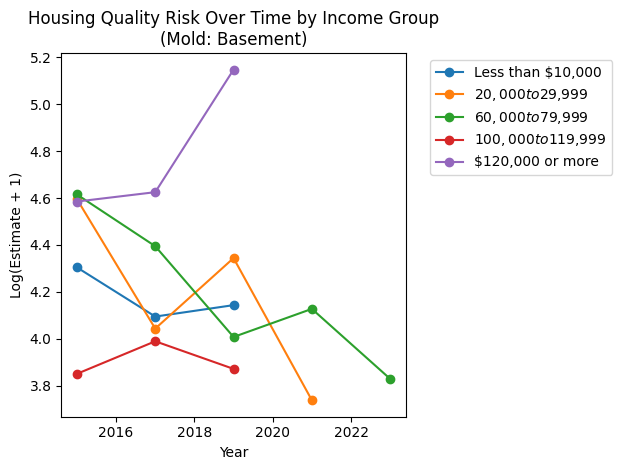

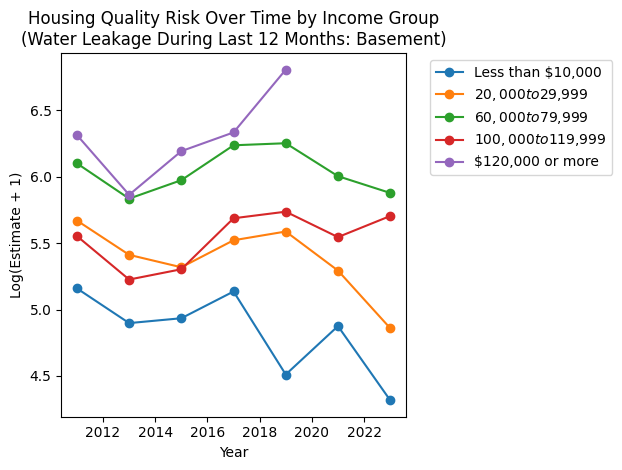

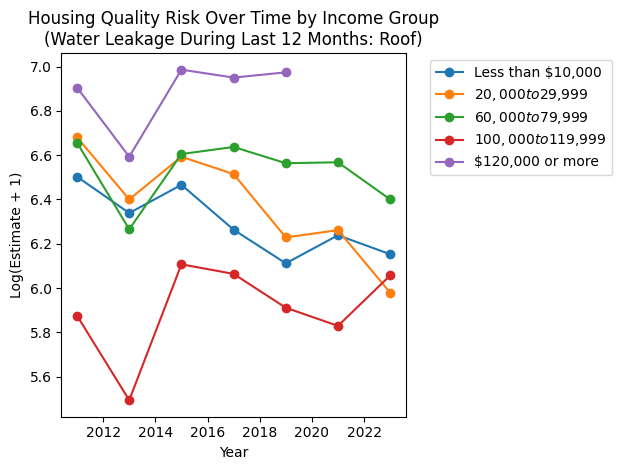

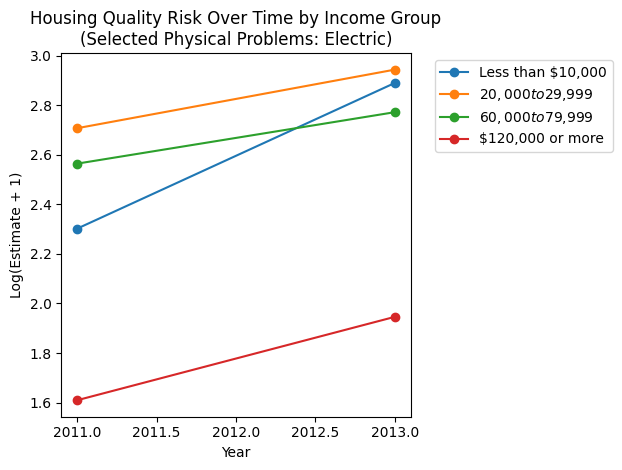

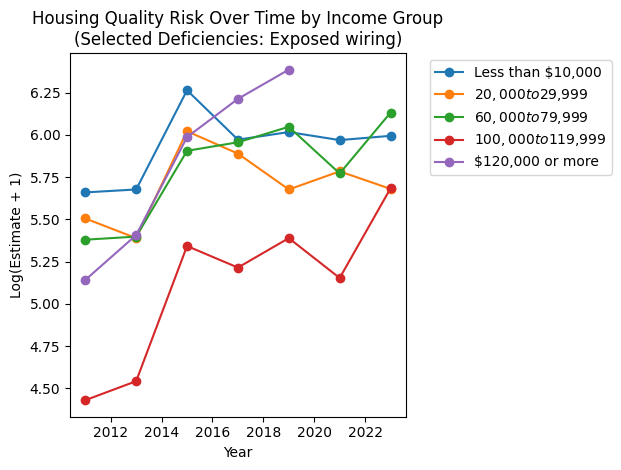

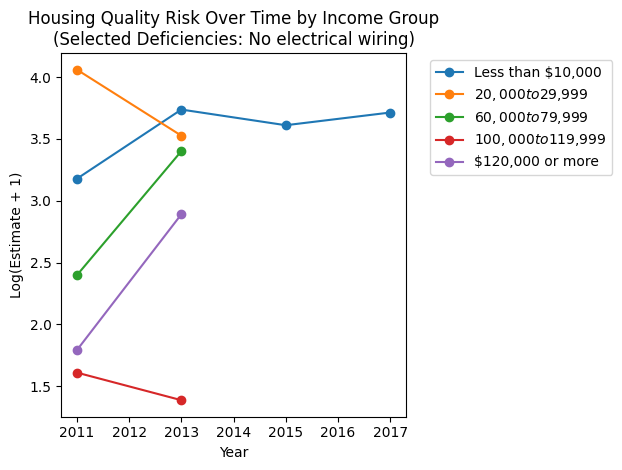

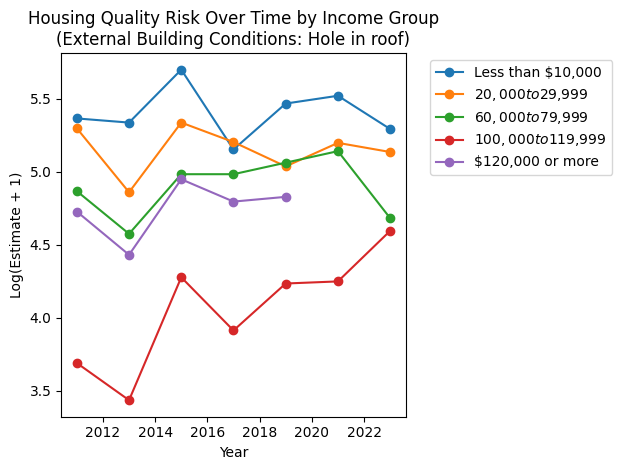

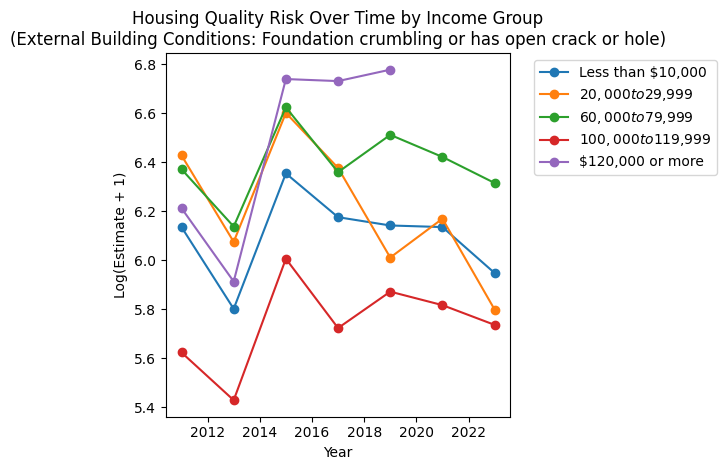

In [6]:
# Performs Time-Based Exploratory Data Analysis by plotting different housing quality risks change over time across different income groups
import matplotlib.pyplot as plt

# Pick a small set of income groups because can't fit all the years
keep_groups = [
    "Less than $10,000",
    "$20,000 to $29,999",
    "$60,000 to $79,999",
    "$100,000 to $119,999",
    "$120,000 or more"
]

risks_to_plot = [
    # Mold by room
    ("Mold", "Basement"),

    # Water leakage (inside/outside structure)
    ("Water Leakage During Last 12 Months", "Basement"),
    ("Water Leakage During Last 12 Months", "Roof"),

    # Electrical / physical issues
    ("Selected Physical Problems", "Electric"),
    ("Selected Deficiencies", "Exposed wiring"),
    ("Selected Deficiencies", "No electrical wiring"),

    # Structural/exterior building hazards
    ("External Building Conditions", "Hole in roof"),
    ("External Building Conditions", "Foundation crumbling or has open crack or hole"),
]
for section_name, characteristic_name in risks_to_plot:

    plot_df = analysis_df[
        (analysis_df["section"] == section_name) &
        (analysis_df["characteristic"] == characteristic_name) &
        (analysis_df["income_group"].isin(keep_groups)) &
        (analysis_df["flag"] == "ok")
    ].copy()

    if plot_df.empty:
        print(f"⚠️ No data found for: {section_name} / {characteristic_name}")
        continue

    plot_df = plot_df.sort_values(["income_group", "year"])

    plt.figure()
    for g in keep_groups:
        sub = plot_df[plot_df["income_group"] == g].dropna(subset=["estimate_log"])
        if not sub.empty:
            plt.plot(sub["year"], sub["estimate_log"], marker="o", label=g)

    plt.xlabel("Year")
    plt.ylabel("Log(Estimate + 1)")
    plt.title(f"Housing Quality Risk Over Time by Income Group\n({section_name}: {characteristic_name})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Research question: How do housing quality–related safety risks, a key social determinant of health, vary by household income in the United States from 2011 to 2023 (biennial)?

Answer: housing risks appear across all income groups, but the patterns and severity differ by income level and by type of housing problem.

(Higher log estimate → higher predicted probability of an event and vice versa.)


### Basement Mold Risk by Income Group

Key Observations:

• Higher-income households (\$120,000+) show an increase in reported basement mold by 2019.

• Middle-income households (\\$60,000 – \\$79,999) display a gradual decline in mold exposure across the study period.

• The \\$20,000 - \\$29,000 group shows the sharpest decrease by 2021.

• The lowest income group (<$10,000) remains relatively stable, suggesting persistent housing quality risks.

. Summary: Besides for the highest income group (\$120,000), all other income groups show a decline in mold in basement.

## Water leakage in basement during last 12 months by income groups

Key Observations:

• Higher-income households (>\$120,000) show the highest log estimate of water leakage during most of the years, with the highest peak in 2019.

. \\$100,000-\\$120,000 households are relatively stable, with minor fluctuations.

• Middle-income households (\\$60,000 – \\$79,999) display moderately high risks, with minor increase from 2013-2019.

• The \\$20,000 – \\$29,999 group has reletively low risks, with a significantly decrease in 2023.

• The lowest income group (<$10,000) remains the lowest, with sharp decline in 2023.

## Water leakage in roof during last 12 months by income groups

Key Observations:

• Higher-income households (>\$120,000) show the highest log estimate of water leakage out of all the groups, except for a dip in 2013 but it remains pretty stable throughout the years.

. \\$100,000-\\$120,000 has lowest log estimate of water leakge in roof, with a dip in 2013, but remains pretty stable afterwards.

• Middle-income households (\\$60,000 – \\$79,999) display moderately high risks, with a dip in 2013, but remains stable throughout the years.

• The \\$20,000 – \\$29,999 group has reletively high risks of water leakage in roof, with a dip in 2013, and increases a little bit afterwards, but decreases significantly since 2023.

• The lowest income group (<$10,000) has relatiely high risks, with a dip in 2013, but has decresed a little bit since 2019.

Summary: >\\$120,000 group has highest risks of water leakage udring the last 12 months in roof over the years. While the 2nd highest income has the lowest risks. The lower income groups (\\$79,999 and below) all have pretty high risks of water leakage in roof, but have decrease since recently.

## Selected Physical Problems: Electric

Key Observations:

• Higher-income households (>\$120,000) show the lowest risks.

. All the others (exceptfor \\$100,000-\\$119,999 because lacks data) show high risks.

. All of the above have positive slopes (they all increase the rates over the years)

## Selected Deficiencies: Exposed wiring

Key Observations:

• Higher-income households (>\$120,000) has 2nd highest rates, and it's still increasing rapidly.

. \\$100,000-\\$120,000 households have lowest rates of exposed wiring, with increasing fluctuations.

• Middle-income households (\\$60,000 – \\$79,999) display moderately high risks, with minor increase over the years.

• The \\$20,000 – \\$29,999 group has varying fluctuations.

• The lowest income group (<$10,000) has the highest risks of exposed wiring, and remains stable since recent.

Summary: The \\$100,000-\\$119,999, <\\$120,000 and <\\$10,0000 risks have been decreasing since 2023. All the income groups have high increases in 2015. Middle income groups have more issues with exposed wiring (>\\$120,000 has it because it may have more wirings that come from bigger or more complex houses.)

## Selected Deficiencies: No electrical wiring

Key Observations:

• <\\$10,000 has an increased log estimate in 2913, but has remained stable ever since.

. The other groups only have data from 2011-2013.

## External Building Conditions: Hole in roof

Key Observations:

• Higher-income households (>\$120,000) has a moderate log estimate, with a dip in 2013, but incrased back in 2015, and remained stable.

. \\$100,000-\\$120,000 households have lowest rates of hole in roof, with a dip in 2013, and have been steadily increasing.  

• Middle-income households (\\$60,000 – \\$79,999) display moderately high risks, with minor increase, and a significantly decrease since 2023.

• The \\$20,000 – \\$29,999 group has high log estimates, with a dip in 2013, increased back in 2015, but has steadily declined ever since.

• The lowest income group (<$10,000) has the highest risks of hole in roof, dipped down in 2013, increased back in 2015, dipped down again in 2917, and remained stable since.

Summary: All groups have a a dip (the lowest log estimate = lowest predicted probability of hole in group in 2013), then their rates all increased in 2015.

## External Building Conditions: Foundation crumbling or has open crack or hole

Key Observations:

• Higher-income households (>\$120,000) has a moderate high log estimate, with a dip in 2013, but incrased back in 2015, and remained stable.

. \\$100,000-\\$120,000 households have lowest rates, with a dip in 2013, increased back in 2015 and have been steadily increasing.  

• Middle-income households (\\$60,000 – \\$79,999) display moderately high risks, with a dip in 2013, increased back in 2015, but have been decreasing since then.

• The \\$20,000 – \\$29,999 group has moderately high log estimates, with a dip in 2013, increased back in 2015, but has significantly declined ever since.

• The lowest income group (<$10,000) has relatively low risks, dipped down in 2013, increased back in 2015, and has been steadily declining.

Summary: All groups have a a dip (the lowest log estimate = lowest predicted probability of hole in group in 2013), then their rates all increased in 2015. All groups' rates have been declining since 2023. Middle-income households ($60,000–$79,999) often show relatively high levels of these structural issues over time

##Overall summary:
. Housing safety risks are not limited to a single income group.

. Water-related issues (leakage and mold) appear more frequently in higher-income households in the estimates.

. Electrical deficiencies tend to be more common in lower-income households.

. Structural problems are present across income groups with fluctuating trends over time.